# Ames Housing - Neural Network regressie

Doel: met een neural network de huizenprijzen (`SalePrice`) voorspellen en onderzoeken welke feature set het beste werkt. De resultaten worden vergeleken met lineaire regressie op dezelfde vaste testset.

De experimenten staan in `run_ames_nn_experiments.py`. Dat script draait 540 NN-experimenten met verschillende feature sets, validation-groottes, learning rates, epochs en hidden-layer configuraties.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd()
if not (BASE_DIR / "run_ames_nn_experiments.py").exists():
    BASE_DIR = Path.cwd() / "Week 9 ML"

RESULTS_DIR = BASE_DIR / "ames_nn_results"
RESULTS_DIR

PosixPath('/Users/cmok/Documents/GitHub/DEAI-SE4/Week 9 ML/ames_nn_results')

## Experimenten draaien

Deze cel hoeft alleen opnieuw uitgevoerd te worden als je de experimenten opnieuw wilt berekenen. De huidige resultaten zijn al opgeslagen in `ames_nn_results/`.

In [2]:
# Duurt enkele minuten: 540 experimenten.
# %run run_ames_nn_experiments.py

## Resultaten laden

In [3]:
nn_results = pd.read_csv(RESULTS_DIR / "ames_nn_experiment_results.csv")
comparison = pd.read_csv(RESULTS_DIR / "ames_nn_vs_linear_comparison.csv")

print("Aantal NN-experimenten:", len(nn_results))
print("Feature sets:", nn_results["feature_set"].nunique())
nn_results.head()

Aantal NN-experimenten: 540
Feature sets: 6


,model_type,feature_set,features,n_features_before_encoding,validation_size,architecture,hidden_layers,hidden_nodes,learning_rate,epochs,train_rows,validation_rows,test_rows,train_seconds,validation_r2,validation_mae,validation_rmse,test_r2,test_mae,test_rmse
0,NeuralNetwork_MLP,lr_basis,"Overall Qual, Gr Liv Area, Neighborhood",3,0.15,1x32,1,"(32,)",0.0100,300,1992,352,586,0.200713,0.826842,18926.376949,27770.537963,0.881453,20901.747981,30829.446235
1,NeuralNetwork_MLP,lr_basis,"Overall Qual, Gr Liv Area, Neighborhood",3,0.15,1x32,1,"(32,)",0.0100,800,1992,352,586,0.206066,0.826842,18926.376949,27770.537963,0.881453,20901.747981,30829.446235
2,NeuralNetwork_MLP,lr_basis,"Overall Qual, Gr Liv Area, Neighborhood",3,0.15,1x32,1,"(32,)",0.0010,300,1992,352,586,0.665775,0.829860,19209.230561,27527.404836,0.880331,21234.254230,30975.084537
3,NeuralNetwork_MLP,lr_basis,"Overall Qual, Gr Liv Area, Neighborhood",3,0.15,1x32,1,"(32,)",0.0010,800,1992,352,586,0.660158,0.829860,19209.230561,27527.404836,0.880331,21234.254230,30975.084537
4,NeuralNetwork_MLP,lr_basis,"Overall Qual, Gr Liv Area, Neighborhood",3,0.15,1x32,1,"(32,)",0.0003,300,1992,352,586,0.954650,0.833381,18870.021822,27241.090962,0.878773,21272.856014,31176.045783


## Beste neural-network modellen

Modelkeuze gebeurt op basis van de validation RMSE. Daarna bekijken we de test RMSE en R2 als eindcontrole.

In [4]:
top_10 = nn_results.sort_values("validation_rmse").head(10)
top_10[[
    "feature_set",
    "validation_rmse",
    "validation_mae",
    "validation_r2",
    "test_rmse",
    "test_mae",
    "test_r2",
    "architecture",
    "learning_rate",
    "epochs",
    "validation_size",
]]

,feature_set,validation_rmse,validation_mae,validation_r2,test_rmse,test_mae,test_r2,architecture,learning_rate,epochs,validation_size
474,alle_features_zonder_id,23230.781101,16414.109945,0.878828,27923.837427,18149.066787,0.902746,3x128_64_32,0.0100,300,0.15
475,alle_features_zonder_id,23230.781101,16414.109945,0.878828,27923.837427,18149.066787,0.902746,3x128_64_32,0.0100,800,0.15
394,sterke_subset,23479.319124,16755.821452,0.886475,27825.561884,18009.751288,0.903429,1x32,0.0003,300,0.20
395,sterke_subset,23479.319124,16755.821452,0.886475,27825.561884,18009.751288,0.903429,1x32,0.0003,800,0.20
365,sterke_subset,23550.899884,16658.239883,0.875466,28036.013115,18256.426260,0.901963,1x32,0.0003,800,0.15
485,alle_features_zonder_id,23606.009022,16993.490529,0.885247,26579.819782,17364.817574,0.911882,1x32,0.0003,800,0.20
484,alle_features_zonder_id,23606.009022,16993.490529,0.885247,26579.819782,17364.817574,0.911882,1x32,0.0003,300,0.20
364,sterke_subset,23638.778247,16763.840641,0.874534,28155.109587,18368.161960,0.901128,1x32,0.0003,300,0.15
270,numeriek_alles,23676.784549,17412.202571,0.874131,32707.207332,18516.199401,0.866572,1x32,0.0100,300,0.15
271,numeriek_alles,23676.784549,17412.202571,0.874131,32707.207332,18516.199401,0.866572,1x32,0.0100,800,0.15


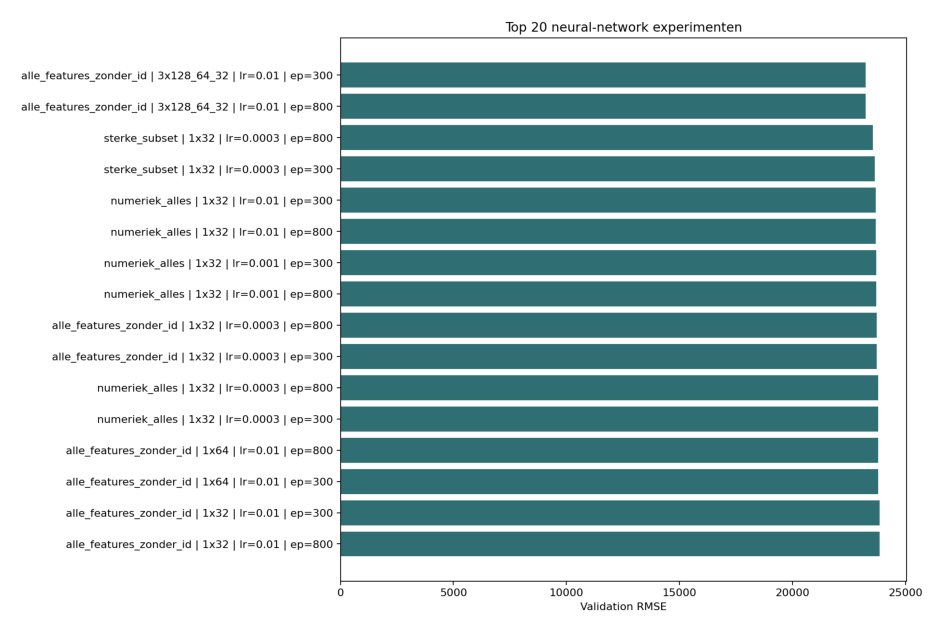

In [5]:
img = plt.imread(RESULTS_DIR / "top_20_nn_validation_rmse.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off");

## Feature sets vergelijken

In [6]:
comparison_sorted = comparison.sort_values("validation_rmse")
comparison_sorted[[
    "feature_set",
    "validation_rmse",
    "test_rmse_nn",
    "test_rmse_linear",
    "test_r2_nn",
    "test_r2_linear",
    "architecture",
    "learning_rate",
    "epochs",
    "validation_size",
    "rmse_verschil_nn_min_linear",
]]

,feature_set,validation_rmse,test_rmse_nn,test_rmse_linear,test_r2_nn,test_r2_linear,architecture,learning_rate,epochs,validation_size,rmse_verschil_nn_min_linear
0,alle_features_zonder_id,23230.781101,27923.837427,35872.989694,0.902746,0.839493,3x128_64_32,0.0100,300,0.15,-7949.152267
1,sterke_subset,23479.319124,27825.561884,36692.016969,0.903429,0.832080,1x32,0.0003,300,0.20,-8866.455085
2,numeriek_alles,23676.784549,32707.207332,39900.218406,0.866572,0.801432,1x32,0.0100,300,0.15,-7193.011074
3,lr_uitgebreid,24040.505156,28654.307049,36698.129855,0.897591,0.832024,1x64,0.0010,800,0.20,-8043.822806
4,lr_met_housestyle,24410.582570,28295.756798,37035.851675,0.900138,0.828918,1x32,0.0010,800,0.20,-8740.094878
5,lr_basis,26685.076387,30631.962464,39052.450389,0.882967,0.809781,1x64,0.0003,300,0.15,-8420.487925


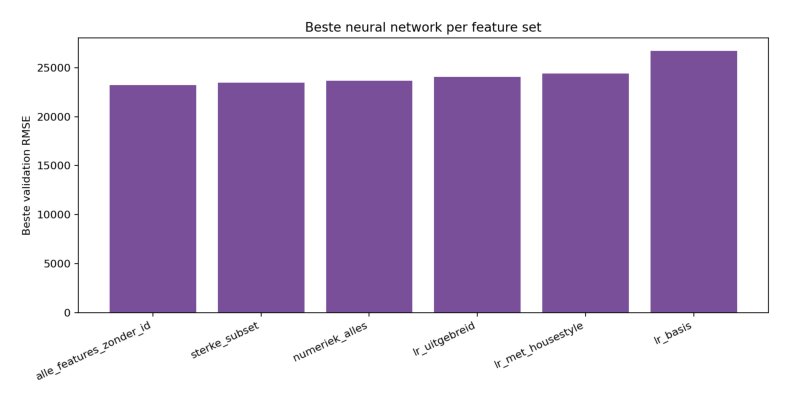

In [7]:
img = plt.imread(RESULTS_DIR / "best_feature_sets_validation_rmse.png")
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis("off");

## Conclusie

De beste configuratie op validation RMSE gebruikt `alle_features_zonder_id`: `Garage`, `Overall Qual`, `Gr Liv Area`, `Total Bsmt SF`, `Lot Area`, `Year Built`, `Full Bath`, `Bedroom AbvGr`, `Neighborhood` en `House Style`. De beste setting was een neural network met 3 hidden layers `(128, 64, 32)`, learning rate `0.01`, `300` epochs en validation size `0.15`. Dit model haalde validation RMSE `23230.78`, test RMSE `27923.84` en test R2 `0.9027`.

Alle features leveren dus de beste validation-score op. Toch is het verschil met de `sterke_subset` klein: deze subset gebruikt minder features en haalt validation RMSE `23479.32`, test RMSE `27825.56` en test R2 `0.9034`. Op de testset is die kleinere subset zelfs iets beter, maar omdat de opdracht expliciet een validation set gebruikt voor modelkeuze, is `alle_features_zonder_id` de beste keuze volgens de afgesproken selectieprocedure.

Vergeleken met lineaire regressie presteert het neural network duidelijk beter voor iedere feature set. Voor de beste feature set daalt de test RMSE van `35872.99` bij lineaire regressie naar `27923.84` bij het neural network. De test R2 stijgt daarbij van `0.8395` naar `0.9027`.

De belangrijkste les: meer features helpen hier, maar niet onbeperkt overtuigend. Een compacte subset met kwaliteit, woonoppervlak, kelderoppervlak, bouwjaar, badkamers en buurt komt bijna even ver. Voor uitlegbaarheid zou die subset aantrekkelijk zijn; voor de beste validation-score wint het volledige model zonder `ID`.